In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

#### Verification: If you would like to see verification result, execute the following block(the second block) and comment the third block

In [30]:
# Verificaiton 
# -------------------
# 1) Column/Material Properties and assumptions(Inputs)
# -------------------
EI1L = 152000 # scale??????????????????????????????????????????????????????????????
EI1R = 152000
EI2L = 152000
EI2R = 152000
EI3L = 152000
EI3R = 152000

# Story heights (inches):
h1 = 4 #m
h2 = 4
h3 = 4

# Dead Mass
mass = 45000 # kg
m1_dead = mass   
m2_dead = mass
m3_dead = mass/2

# Coefficient for live to dead load
coeff = 1

# live to dead(we don't have live load)
m1_live = 0 # m1_dead / coeff
m2_live = 0 # m2_dead / coeff
m3_live = 0 # m3_dead / coeff

# We won't vary the live-load portion alpha for verification mode.
num_point = 1
max_live_portion = 1
min_live_portion = 1

# Compute each story stiffness (2 columns in parallel), I put stiffness here because we can change the equation if frame changes
k1L = 12.0 * EI1L / (h1**3)
k1R = 12.0 * EI1R / (h1**3)
k2L = 12.0 * EI2L / (h2**3)
k2R = 12.0 * EI2R / (h2**3)
k3L = 12.0 * EI3L / (h3**3)
k3R = 12.0 * EI3R / (h3**3)

# Correct result
w1_correct = 2.5359 *np.sqrt(EI1L/(mass*h1**3))
w2_correct = 6.9282 *np.sqrt(EI2L/(mass*h2**3))
w3_correct = 9.4641 *np.sqrt(EI3L/(mass*h3**3))

print(f" Correct Circular frequencies (rad/sec) 1 is: {w1_correct}")
print(f" Correct Circular frequencies (rad/sec) 2 is: {w2_correct}")
print(f" Correct Circular frequencies (rad/sec) 3 is: {w3_correct}")

 Correct Circular frequencies (rad/sec) 1 is: 0.5825828205070932
 Correct Circular frequencies (rad/sec) 2 is: 1.591644109403858
 Correct Circular frequencies (rad/sec) 3 is: 2.1742269299109513


#### If you would like to see the result for original question, comment the upper block and execute the following block

In [4]:
# # Example
# # -------------------
# # 1) Column/Material Properties and assumptions(Inputs)
# # -------------------
# E   = 29000.0       # ksi (typical steel)
# # For a W14x120, strong-axis I is ~650 to 660 in^4 (depends on the exact table).
# I1L  = 657.0         # in^4 (example)
# I1R  = 657.0         # in^4 (example)
# I2L  = 657.0         # in^4 (assuming same cross-section)
# I2R  = 657.0         # in^4 (assuming same cross-section)
# I3L  = 657.0         # in^4 (assuming same cross-section)
# I3R  = 657.0         # in^4 (assuming same cross-section)

# # Story heights (inches):
# h1 = 180.0  # e.g., 15 ft = 180 in
# h2 = 180.0
# h3 = 180.0

# # Dead Mass
# m1_dead = 0.24   # kip*s^2/in
# m2_dead = 0.24
# m3_dead = 0.12

# # Coefficient for live to dead load
# coeff = 3

# # live to dead
# m1_live = m1_dead / coeff
# m2_live = m2_dead / coeff
# m3_live = m3_dead / coeff

# # We will vary the live-load portion alpha in [0.25, 0.75]
# num_point = 6
# max_live_portion = 0.75
# min_live_portion = 0.25

# # Compute each story stiffness (2 columns in parallel), I put stiffness here because we can change the equation if frame changes
# k1L = 12.0 * E * I1L / (h1**3)
# k1R = 12.0 * E * I1R / (h1**3)
# k2L = 12.0 * E * I2L / (h2**3)
# k2R = 12.0 * E * I2R / (h2**3)
# k3L = 12.0 * E * I3L / (h3**3)
# k3R = 12.0 * E * I3R / (h3**3)

In [5]:
def build_mass_matrix(m1, m2, m3):
    """
    Returns a 3x3 diagonal mass matrix [M].
    """
    return np.diag([m1, m2, m3])

def build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R):
    """
    Returns a 3x3 stiffness matrix [K] for a 3-DOF shear building.
    """
    # First floor
    k1 = k1L+k1R
    # Second floor
    k2 = k2L+k2R
    # Third floor
    k3 = k3L+k3R
    
    return np.array([
        [k1 + k2,   -k2,       0   ],
        [    -k2,   k2 + k3,   -k3 ],
        [     0,       -k3,    k3  ]
    ])

Matrix M = [[45000.     0.     0.]
 [    0. 45000.     0.]
 [    0.     0. 22500.]]
----------------------------------------------------------------------
Matrix K = [[114000. -57000.      0.]
 [-57000. 114000. -57000.]
 [     0. -57000.  57000.]]
----------------------------------------------------------------------
alpha = 1.00
Circular frequencies (rad/sec): [0.58258245 1.59164485 2.1742273 ]
Frequencies (Hz): [0.09272088 0.25331815 0.34603902]
----------------------------------------------------------------------
Mode shapes (floor1, floor2, floor3) normalized:
  Mode 1: [0.5       0.8660254 1.       ]
  Mode 2: [-1.00000000e+00 -3.42052984e-16  1.00000000e+00]
  Mode 3: [ 0.5       -0.8660254  1.       ]
----------------------------------------------------------------------


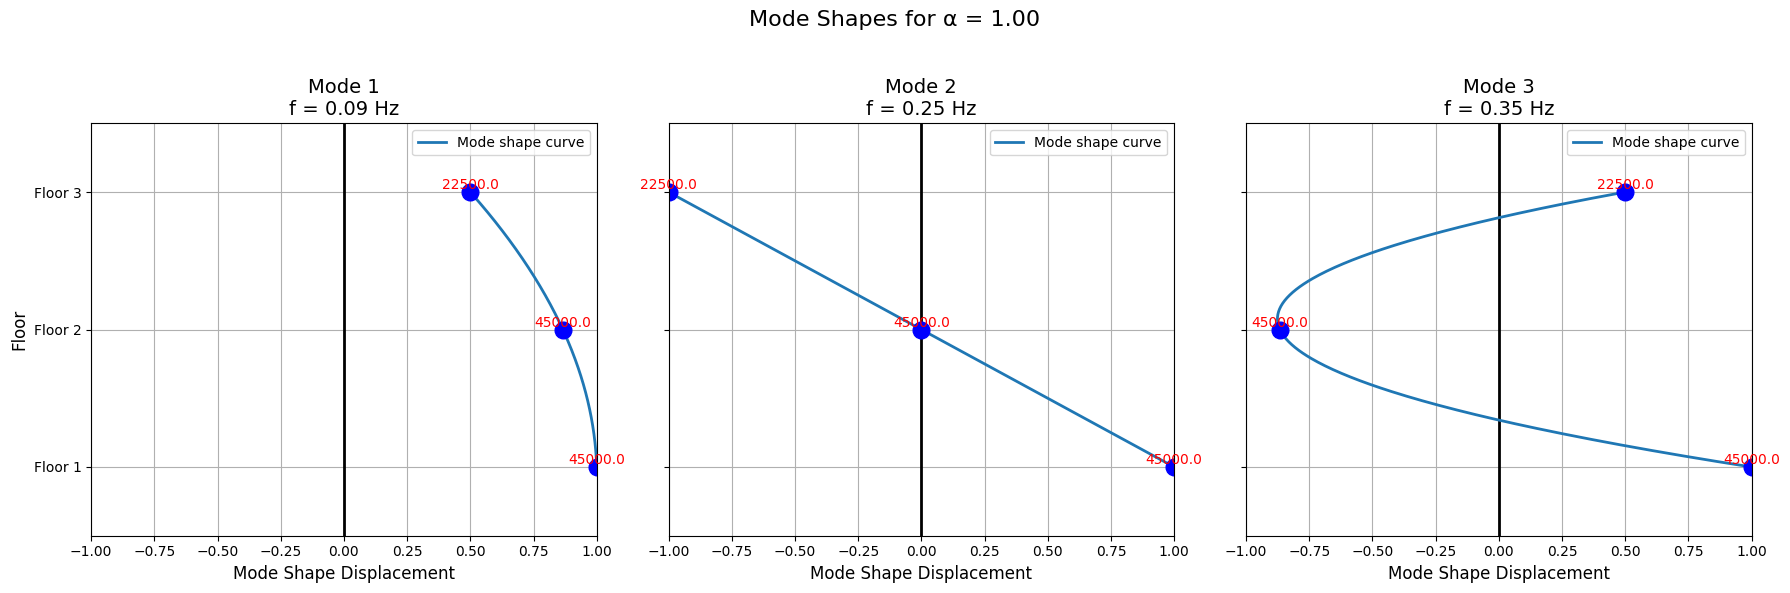

Summary of frequencies vs. alpha:
 alpha |   f1(Hz)    f2(Hz)    f3(Hz)
  1.00 |    0.0927    0.2533    0.3460


In [50]:
# -------------------
# 2) Masses and live load variation
# -------------------
# We will vary the live-load portion alpha in [0.25, 0.75].
alpha_values = np.linspace(min_live_portion, max_live_portion, num_point)  # For example 6 points: 0.25, 0.35, ..., 0.75


# Prepare containers to store mode shape data for plotting.
# For each mode (mode 1, mode 2, mode 3), we store a list of tuples (alpha, mode_shape vector)
mode_shapes_all = {1: [], 2: [], 3: []}
                   

# Prepare arrays to store results
freqs_array = []  # will store [alpha, f1, f2, f3] in each row

for alpha in alpha_values:
    # Compute total masses for this alpha:
    m1 = m1_dead + alpha*m1_live
    m2 = m2_dead + alpha*m2_live
    m3 = m3_dead + alpha*m3_live

    # Build M, K
    M = build_mass_matrix(m1, m2, m3)
    K = build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R)

    print(f"Matrix M = {M}")
    print("-"*70)
    print(f"Matrix K = {K}")
    print("-"*70)

    # Transform the generalized problem to a standard one:
    A = np.linalg.inv(M).dot(K)

    # Solve the generalized eigenvalue problem: K phi = w^2 M phi --> inv(M)*K * phi = w^2 phi. Now solve A*phi = lambda*phi:
    # In Our case, M is a diagonal matrix, so computing its inverse explicitly with np.linalg.inv(M) is not problematic. For more complex or near-singular M, 
    # it might be more robust to use a generalized eigenvalue solver available in SciPy (e.g., scipy.linalg.eig or scipy.linalg.eigh)
    eigvals, eigvecs = np.linalg.eig(A)

    # Compute circular frequencies and convert to natural freq in Hz
    # Why abs: In dynamic problems, the eigenvalues λ should theoretically be nonnegative since they represent ω2
    # squared circular frequencies). However, due to small round‑off errors in numerical computations, yweou might occasionally see a very tiny negative eigenvalue. 
    w = np.sqrt(np.abs(eigvals))           # rad/s
    freq = w / (2.0*np.pi)                 # Hz

    # Store the results:
    freqs_array.append([alpha, freq[0], freq[1], freq[2]])

    # Print out mode shapes (normalized so that the top entry = 1, etc.)
    # Let’s say we want to keep them consistent: for each mode i, we can normalize so that the largest displacement component is 1.
    mode_shapes = []
    for i in range(3):
        mode_i = eigvecs[:, i]
        mode_i /= np.max(np.abs(mode_i))  # largest component = 1
        mode_shapes.append(mode_i)
        # Store for plotting: key is mode index (1-based)
        mode_shapes_all[i+1].append((alpha, mode_i))

    # Print results for the current alpha value:
    print(f"alpha = {alpha:.2f}")
    print("Circular frequencies (rad/sec):", w)
    print("Frequencies (Hz):", freq)
    print("-"*70)
    print("Mode shapes (floor1, floor2, floor3) normalized:")
    for i, shape in enumerate(mode_shapes, start=1):
        print(f"  Mode {i}: {shape}")
    print("-"*70)




























    num_modes = 3
    
    # Define the vertical positions for each floor.
    # For clarity, we use 1 = Floor 1 (bottom), 2 = Floor 2, and 3 = Floor 3 (top).
    floors = np.array([1, 2, 3])
    # Store the corresponding lumped mass values for annotation.
    mass_values = [m1, m2, m3]

    # Plot settings: create one subplot per mode.
    fig, axes = plt.subplots(1, num_modes, figsize=(18, 6), sharey=True)
    mode_names = ['Mode 1', 'Mode 2', 'Mode 3']

    # For smooth interpolation of the mode shape curve, we use a quadratic spline interpolation.
    # With only three points, a quadratic (k=2) spline gives a smooth curve.
    for i in range(num_modes):
        ax = axes[i]

        # For each mode, take the mode shape corresponding to the final alpha value.
        # Here, mode_shapes_all[i+1] is a list of tuples (alpha, mode_shape vector) and [-1][1] selects the mode shape from the last alpha in the list.
        # Because our computed mode shape vector is ordered in reverse of our floor numbering, I  use the flip.
        mode_shape_i = np.flip(mode_shapes_all[i+1][-1][1])
        
        # Create a fine vertical grid for smooth curve (using the floor positions as the parameter).
        y_fine = np.linspace(floors.min(), floors.max(), 300)
        # Create the quadratic spline (k=2) mapping floor (y) to displacement (x).
        spline = make_interp_spline(floors, mode_shape_i, k=2)
        x_fine = spline(y_fine)
        
        # Draw a vertical reference line representing the structure (at x = 0).
        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
        
        # Plot the smooth mode shape curve (x_fine vs. y_fine)
        ax.plot(x_fine, y_fine, '-', linewidth=2, label='Mode shape curve')
        
        # Plot the lumped masses as circles at each floor (using the mode shape displacement at that floor)
        for j, (x_val, y_val) in enumerate(zip(mode_shape_i, floors)):
            ax.plot(x_val, y_val, 'o', markersize=12, color='blue')
            # Annotate the point with the lumped mass value (formatted to 1 decimal place)
            ax.text(x_val, y_val, f'\n{mass_values[j]:.1f}', ha='center', va='bottom', fontsize=10, color='red')
        
        # Set axis labels and title.
        rep_freq = freqs_array[-1]  # This is something like [alpha, f1, f2, f3]
        # This ensures that for mode i (i = 0, 1, 2), we use rep_freq[i+1].
        ax.set_title(f'{mode_names[i]}\nf = {rep_freq[i+1]:.2f} Hz', fontsize=14)
        ax.set_xlabel('Mode Shape Displacement', fontsize=12)
        if i == 0:
            ax.set_ylabel('Floor', fontsize=12)
        # Adjust y-axis to show all floors comfortably.
        ax.set_ylim(0.5, 3.5)
        ax.set_yticks(floors)
        ax.set_xlim(-1, 1) # to compare better figures
        ax.set_yticklabels(['Floor 1', 'Floor 2', 'Floor 3'])
        ax.legend()
        ax.grid(True)

    plt.suptitle(f'Mode Shapes for α = {alpha_values[-1]:.2f}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
















# Convert frequency summary to NumPy array for further processing or plotting.
freqs_array = np.array(freqs_array)
print("Summary of frequencies vs. alpha:")
print(" alpha |   f1(Hz)    f2(Hz)    f3(Hz)")
for row in freqs_array:
    print(f"{row[0]:6.2f} | {row[1]:9.4f} {row[2]:9.4f} {row[3]:9.4f}")


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from openseespy import opy
from openseespy import postprocessing as opsvis

# Example OpenSees model (simplified)
opy.model('basic', '-ndm', 2, '-ndf', 2)
opy.node(1, 0, 0)
opy.node(2, 10, 0)
opy.fix(1, 1, 1)
opy.element('elasticBeamColumn', 1, 1, 2, 1000, 100, 1)

# Eigenvalue analysis
num_modes = 3
eigenvalues = opy.eigen(num_modes)

# Get node coordinates
node_coords = {}
for node_tag in opy.getNodeTags():
    node_coords[node_tag] = opy.nodeCoord(node_tag)

# Plot mode shapes
for mode_index in range(1, num_modes + 1):
  plt.figure()
  plt.title(f"Mode Shape {mode_index}")

  # Plot undeformed shape
  x_undeformed = [node_coords[tag][0] for tag in node_coords]
  y_undeformed = [node_coords[tag][1] for tag in node_coords]
  plt.plot(x_undeformed, y_undeformed, 'k-', label='Undeformed')

  # Get mode shape displacements
  mode_shape = opy.nodeEigenvector(2, mode_index)

  # Scale displacements (adjust scale_factor as needed)
  scale_factor = 1.0
  x_deformed = [node_coords[tag][0] + mode_shape[i*2]* scale_factor for i, tag in enumerate(node_coords)]
  y_deformed = [node_coords[tag][1] + mode_shape[i*2 + 1]* scale_factor for i, tag in enumerate(node_coords)]

  # Plot deformed shape
  plt.plot(x_deformed, y_deformed, 'r-', label='Deformed')
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.legend()
  plt.grid(True)
  plt.show()

ImportError: cannot import name 'opy' from 'openseespy' (e:\pytorch_env\lib\site-packages\openseespy\__init__.py)